# 01 — Data Exploration: French Insurance Reviews

**Objective:** Load 35 Excel files of French insurance reviews, combine into a single dataset, explore schema & distributions, and document all data quality issues.

**Output:** `data/raw_combined.csv` — 34,435 rows, unmodified, with `source_file` column (avis_cor/avis_cor_en dropped)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from collections import Counter
from wordcloud import WordCloud
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('Traduction avis clients')
OUT_DIR = Path('data')
OUT_DIR.mkdir(exist_ok=True)

EN_STOPWORDS = set(stopwords.words('english'))

print('Setup complete.')

Setup complete.


---
## 1a — Load & Concatenate All 35 Files

In [2]:
files = sorted(DATA_DIR.glob('avis_*_traduit.xlsx'), key=lambda f: int(f.stem.split('_')[1]))
print(f'Found {len(files)} Excel files.')

dfs = []
for f in files:
    tmp = pd.read_excel(f)
    tmp['source_file'] = f.name
    dfs.append(tmp)
    print(f'  {f.name}: {len(tmp)} rows, {list(tmp.columns[:5])}...')

df = pd.concat(dfs, ignore_index=True)
print(f'\nCombined shape: {df.shape}')
print(f'Total rows: {len(df):,}')

Found 35 Excel files.


  avis_1_traduit.xlsx: 1000 rows, ['note', 'auteur', 'avis', 'assureur', 'produit']...


  avis_2_traduit.xlsx: 1000 rows, ['note', 'auteur', 'avis', 'assureur', 'produit']...


  avis_3_traduit.xlsx: 1000 rows, ['note', 'auteur', 'avis', 'assureur', 'produit']...


  avis_4_traduit.xlsx: 1000 rows, ['note', 'auteur', 'avis', 'assureur', 'produit']...


...

  avis_30_traduit.xlsx: 1000 rows, ['note', 'auteur', 'avis', 'assureur', 'produit']...


  avis_31_traduit.xlsx: 1000 rows, ['note', 'auteur', 'avis', 'assureur', 'produit']...


  avis_32_traduit.xlsx: 1000 rows, ['note', 'auteur', 'avis', 'assureur', 'produit']...


  avis_33_traduit.xlsx: 1000 rows, ['note', 'auteur', 'avis', 'assureur', 'produit']...


  avis_34_traduit.xlsx: 1000 rows, ['note', 'auteur', 'avis', 'assureur', 'produit']...
  avis_35_traduit.xlsx: 435 rows, ['note', 'auteur', 'avis', 'assureur', 'produit']...

Combined shape: (34435, 12)
Total rows: 34,435


---
## 1b — Basic Statistics & Schema Overview

In [3]:
print('=== Shape ===')
print(f'{df.shape[0]:,} rows × {df.shape[1]} columns\n')

print('=== Dtypes ===')
print(df.dtypes.to_string())
print()

print('=== Null Counts ===')
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_df = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
print(null_df.to_string())
print()

print('=== Sample Rows ===')
df.head(3)

=== Shape ===
34,435 rows × 12 columns

=== Dtypes ===
note                float64
auteur                  str
avis                    str
assureur                str
produit                 str
type                    str
date_publication        str
date_exp                str
avis_en                 str
avis_cor             object
avis_cor_en          object
source_file             str

=== Null Counts ===


                  null_count  null_pct
note                   10331     30.00
auteur                     1      0.00
avis                       0      0.00
assureur                   0      0.00
produit                    0      0.00
type                       0      0.00
date_publication           0      0.00
date_exp                   0      0.00
avis_en                    2      0.01
avis_cor               34000     98.74
avis_cor_en            34004     98.75
source_file                0      0.00

=== Sample Rows ===


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,source_file
0,5.0,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,06/09/2021,01/09/2021,"Best insurance, price, solutions, listening, s...",NaN,NaN,avis_1_traduit.xlsx
1,4.0,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,03/05/2021,01/05/2021,"I am generally satisfied, except that you have...",NaN,NaN,avis_1_traduit.xlsx
2,5.0,virginie-t-107352,Prix tres abordable plusieurs options s'offren...,Direct Assurance,auto,train,21/03/2021,01/03/2021,Very affordable price Several options are avai...,NaN,NaN,avis_1_traduit.xlsx


In [4]:
# Inspect NaN rows to understand *why* they are NaN
print('=== Sampling NaN rows ===\n')

# auteur: 1 NaN
print('--- auteur NaN (1 row) ---')
mask = df['auteur'].isna()
for idx in df.loc[mask].index:
    row = df.loc[idx]
    print(f'  Row {idx} | avis: "{row["avis"]}"')
    print(f'  assureur: {row["assureur"]} | note: {row["note"]} | source: {row["source_file"]}')
print()

# avis_en: 2 NaN
print('--- avis_en NaN (2 rows) ---')
mask = df['avis_en'].isna()
for idx in df.loc[mask].index:
    row = df.loc[idx]
    print(f'  Row {idx} | source: {row["source_file"]} | note: {row["note"]}')
    print(f'  avis: "{row["avis"]}"')
    print(f'  auteur: {row["auteur"]} | assureur: {row["assureur"]}')
    print()

# note: sample test set
print('--- note NaN (test set) — 3 random samples ---')
mask = df['note'].isna()
for idx, row in df.loc[mask].sample(3, random_state=42).iterrows():
    print(f'  Row {idx} | type: {row["type"]} | assureur: {row["assureur"]}')
    print(f'  avis: "{str(row["avis"])[:120]}"')
    print()

=== Sampling NaN rows ===

--- auteur NaN (1 row) ---
  Row 16217 | avis: "Intervention supprimée à la demande de l'internaute."
  assureur: Intériale | note: 3.0 | source: avis_17_traduit.xlsx

--- avis_en NaN (2 rows) ---
  Row 9999 | source: avis_10_traduit.xlsx | note: 5.0
  avis: "La rapidité du traitement de dossier, de l'envoi des documents nécessaires rapide et de l'amabilité des interlocuteurs ainsi que leur connaissance à chaque questions posées. je conseille L'olivier tant bien pour leurs tarifs mais aussi leurs efficacités"
  auteur: sylvie007-57005 | assureur: L'olivier Assurance

  Row 29867 | source: avis_30_traduit.xlsx | note: nan
  avis: "Aucun"
  auteur: moimeme-51557 | assureur: MACIF

--- note NaN (test set) — 3 random samples ---
  Row 31677 | type: test | assureur: Néoliane Santé
  avis: "Enfin une mutuelle que l'on peut contacter en l'occurrence Georges qui a été attentif et m'a donné la bonne procédure co"

  Row 30192 | type: test | assureur: AMV
  avis: "sati

### NaN Observations

| Column | NaN Count | Root Cause |
|--------|-----------|------------|
| `note` | 10,331 | **Intentional** — these are the `type=test` rows with star ratings withheld for prediction. Not a quality issue. |
| `auteur` | 1 | Review text is *"Intervention supprimee a la demande de l'internaute"* (post removed at user's request). Author was scrubbed — this is a **placeholder row**, not a real review. |
| `avis_en` | 2 | **Row 9999** — normal positive review (L'olivier, auto) not translated; likely a processing glitch at file-10 boundary (last row). **Row 29867** — review is just "Aucun" ("None"), too trivial for translation pipeline. |
| `avis_cor` | 34,000 | Only populated in file 35 (435 rows), 433/435 identical to `avis`. Only 2 actual spelling corrections ("fuire" to "fuir"). **Useless — dropped.** |
| `avis_cor_en` | 34,004 | Same as `avis_cor` but worse — 4 additional NaNs. **Dropped.** |

In [5]:
# Star rating distribution (note column)
print('=== Star Rating (note) Distribution ===')
note_counts = df['note'].value_counts(dropna=False).sort_index()
print(note_counts)
print(f'\nTrain (note is not NaN): {df["note"].notna().sum():,}')
print(f'Test  (note is NaN):      {df["note"].isna().sum():,}')

=== Star Rating (note) Distribution ===
note
1.0     7271
2.0     3716
3.0     3382
4.0     4885
5.0     4850
NaN    10331
Name: count, dtype: int64

Train (note is not NaN): 24,104
Test  (note is NaN):      10,331


In [6]:
# Unique values for categorical columns
for col in ['assureur', 'produit', 'type']:
    uniq = df[col].nunique()
    print(f'=== {col}: {uniq} unique values ===')
    print(df[col].value_counts().head(10).to_string())
    print()

=== assureur: 56 unique values ===
assureur
Direct Assurance       8503
L'olivier Assurance    6080
APRIL Moto             1475
GMF                    1472
Néoliane Santé         1217
MACIF                  1195
AMV                     996
Santiane                953
AXA                     893
MAAF                    881

=== produit: 13 unique values ===
produit
auto                           20157
sante                           5002
moto                            3021
habitation                      2815
prevoyance                      1110
credit                           908
vie                              835
animaux                          523
multirisque-professionnelle       24
garantie-decennale                14

=== type: 2 unique values ===
type
train    24104
test     10331



In [7]:
# Text length statistics
df['avis_len'] = df['avis'].astype(str).str.len()
df['avis_en_len'] = df['avis_en'].astype(str).str.len()

print('=== French Review (avis) Length Stats ===')
print(df['avis_len'].describe().to_string())
print()

print('=== English Translation (avis_en) Length Stats ===')
print(df['avis_en_len'].describe().to_string())

=== French Review (avis) Length Stats ===
count    34435.000000
mean       345.849194
std        385.472878
min          3.000000
25%        161.000000
50%        201.000000
75%        382.000000
max       8770.000000

=== English Translation (avis_en) Length Stats ===
count    34433.000000
mean       311.024308
std        355.147399
min          2.000000
25%        149.000000
50%        184.000000
75%        346.000000
max       8235.000000


### Basic Stats Observations

- **Train/test split is ~70/30** (24,104 train / 10,331 test), defined by `type` column. `note` (star rating) is NaN for all test rows — this is the prediction target.
- **Star distribution is skewed toward 1-star** (7,271 = 30% of train). 2-star is the least common (3,716). This class imbalance will matter for classification.
- **Insurer distribution is heavily skewed**: Direct Assurance (8,503) and L'olivier (6,080) dominate; bottom insurers have <10 reviews (Hiscox: 3). Insurer-level analysis will be unreliable for rare insurers.
- **Product distribution**: `auto` is 58% of all reviews (20,157). Some products have <25 reviews (multirisque-professionnelle: 24, garantie-decennale: 14).
- **Review lengths**: median 201 chars (FR), mean 346 — right-skewed with a long tail up to 8,770 chars. Most reviews are 1-2 paragraphs.
- **FR reviews are ~10% longer than EN translations** on average (346 vs 311 chars), which is expected for FR->EN translation.

---
## 1c — Data Quality Issues

We systematically flag each known quality issue.

In [8]:
# --- Issue #1: "Loading..." translations ---
is_loading = df['avis_en'].astype(str).str.strip().str.lower().isin(['loading...', 'loading…', 'loading'])
print(f'Issue #1 — "Loading..." translations: {is_loading.sum():,} rows ({is_loading.mean()*100:.1f}%)')
print('Sample:')
df.loc[is_loading, ['avis', 'avis_en', 'source_file']].head(3)

Issue #1 — "Loading..." translations: 1,104 rows (3.2%)
Sample:


,avis,avis_en,source_file
13001,"J'ai fait un devis sur le site, devis établis ...",Loading...,avis_14_traduit.xlsx
13002,Il est impossible d'avoir un interlocuteur sér...,Loading...,avis_14_traduit.xlsx
13005,Je suis satisfait et les prix sont correcte ri...,Loading...,avis_14_traduit.xlsx


In [9]:
# --- Issue #2: avis_cor / avis_cor_en mostly NaN ---
cor_nans = df['avis_cor'].isna().sum()
cor_en_nans = df['avis_cor_en'].isna().sum()
print(f'Issue #2 — avis_cor NaN: {cor_nans:,} / {len(df):,} ({cor_nans/len(df)*100:.1f}%)')
print(f'           avis_cor_en NaN: {cor_en_nans:,} / {len(df):,} ({cor_en_nans/len(df)*100:.1f}%)')

# Check where avis_cor is populated
populated = df[df['avis_cor'].notna()]
print(f'\navis_cor populated in {len(populated)} rows from files: {populated["source_file"].unique()}')

# How many are actually different from avis?
if len(populated) > 0:
    actually_corrected = populated[populated['avis'].astype(str) != populated['avis_cor'].astype(str)]
    print(f'Actually corrected (avis != avis_cor): {len(actually_corrected)} rows')
    if len(actually_corrected) > 0:
        for _, row in actually_corrected.head(3).iterrows():
            print(f'  ORIGINAL: {str(row["avis"])[:100]}')
            print(f'  CORRECTED: {str(row["avis_cor"])[:100]}')
            print()

Issue #2 — avis_cor NaN: 34,000 / 34,435 (98.7%)
           avis_cor_en NaN: 34,004 / 34,435 (98.7%)



avis_cor populated in 435 rows from files: <StringArray>
['avis_35_traduit.xlsx']
Length: 1, dtype: str
Actually corrected (avis != avis_cor): 2 rows
  ORIGINAL: A fuire j'ai été en arrêt cas contact  covid 2 semaines plus une semaine de prolongations par mon mé
  CORRECTED: A fuir j'ai été en arrêt cas contact  covid 2 semaines plus une semaine de prolongations par mon méd

  ORIGINAL: je suis en retraite depuis le 1 janvier , toujours rien recu , assurance retraite a fuire , personne
  CORRECTED: je suis en retraite depuis le 1 janvier , toujours rien recu , assurance retraite a fuir , personnel



In [10]:
# --- Issue #3: English reviews in French avis column ---
# Heuristic: if avis contains mostly English words (common EN words not found in FR)
en_indicators = r'\b(the|is|are|was|were|have|has|been|this|that|with|they|their|from|would|could|should|about|which|when|very|good|bad|great|excellent|terrible|worst|best|because|insurance|company|customer|service|claim|policy|recommend)\b'
fr_indicators = r'\b(le|la|les|des|une|est|sont|avec|dans|pour|qui|que|pas|très|bien|mais|cette|tout|fait|mon|mes|sur|par|nous|vous|ils|leur|assurance|contrat|sinistre|compagnie)\b'

en_count = df['avis'].astype(str).str.count(en_indicators)
fr_count = df['avis'].astype(str).str.count(fr_indicators)

# Flag as English if EN words > FR words and at least 3 EN words
is_english_in_french = (en_count > fr_count) & (en_count >= 3)
print(f'Issue #3 — English reviews in French avis column: {is_english_in_french.sum()} rows')
print('\nSample English reviews found in avis column:')
for idx in df.loc[is_english_in_french].head(5).index:
    print(f'  [{idx}] {str(df.loc[idx, "avis"])[:150]}...')
    print()

Issue #3 — English reviews in French avis column: 19 rows

Sample English reviews found in avis column:
  [3659] je suis satisfait du service. Simplicité et bonne écoute
je suis satisfait du service. Simplicité et bonne écoute
je suis satisfait du service. Simpli...

  [6892] Je suis satisfait dj prix et service très bonne offre je suis satisfait du service prix Je suis satisfait dj prix et service très bonne offre je suis ...

  [8155] service utilisé pour assurer rapidement ma nouvelle bmw K1100LT, je suis tres satisfait du service, simple et rapide ! devis obtenu tres rapidement en...

  [9435] Je suis good with the service its fast and cheap alors je vous conseille d'assurer tous vos véhicule avec eprel moto ça vous permet de faire plus d'éc...

  [17215] Je suis satisfait du service proposé afin d'y assurer mon véhicule.
Excellente communication, service client très satisfaisant.
Je recommande ce servi...



In [11]:
# --- Issue #4: Exact duplicate rows ---
cols_for_dedup = [c for c in df.columns if c not in ['source_file', 'avis_len', 'avis_en_len']]
exact_dupes = df.duplicated(subset=cols_for_dedup, keep=False)
print(f'Issue #4 — Exact duplicate rows: {exact_dupes.sum()} rows ({df.duplicated(subset=cols_for_dedup, keep="first").sum()} would be removed by dedup)')
if exact_dupes.sum() > 0:
    print('\nDuplicate rows:')
    display(df.loc[exact_dupes, ['auteur', 'assureur', 'avis', 'source_file']].sort_values('auteur').head(10))

Issue #4 — Exact duplicate rows: 10 rows (5 would be removed by dedup)

Duplicate rows:


,auteur,assureur,avis,source_file
5710,carimanon-129227,GMF,"Je suis satisfaite du service, les prix ne son...",avis_6_traduit.xlsx
14700,carimanon-129227,GMF,"Je suis satisfaite du service, les prix ne son...",avis_15_traduit.xlsx
9370,christophe--94552,Direct Assurance,Je suis satisfait du service en ligne rapport ...,avis_10_traduit.xlsx
21021,christophe--94552,Direct Assurance,Je suis satisfait du service en ligne rapport ...,avis_22_traduit.xlsx
18033,kevin-93662,Direct Assurance,Satisfait très facile A la souscription très b...,avis_19_traduit.xlsx
20343,kevin-93662,Direct Assurance,Satisfait très facile A la souscription très b...,avis_21_traduit.xlsx
18989,marc-david-123517,GMF,Je suis satisfais du service. Rapide et effica...,avis_19_traduit.xlsx
22924,marc-david-123517,GMF,Je suis satisfais du service. Rapide et effica...,avis_23_traduit.xlsx
28656,vacoas974-114197,GMF,je suis satisfait de la rapidité de traitement...,avis_29_traduit.xlsx
28657,vacoas974-114197,GMF,je suis satisfait de la rapidité de traitement...,avis_29_traduit.xlsx


In [12]:
# --- Issue #5: Duplicate review texts (same avis, different metadata) ---
text_dupes = df['avis'].astype(str).duplicated(keep=False)
text_dupe_first = df['avis'].astype(str).duplicated(keep='first')
print(f'Issue #5 — Duplicate review texts: {text_dupes.sum()} rows involved, {text_dupe_first.sum()} extra copies')
if text_dupes.sum() > 0:
    # Show a few examples
    dupe_texts = df.loc[text_dupes, 'avis'].value_counts().head(5)
    print('\nMost repeated review texts:')
    for txt, count in dupe_texts.items():
        print(f'  [{count}x] {str(txt)[:120]}...')

Issue #5 — Duplicate review texts: 97 rows involved, 58 extra copies

Most repeated review texts:
  [16x] Intervention supprimée à la demande de l'internaute....
  [5x] A fuir...
  [3x] RAS...
  [3x] Catastrophique...
  [2x] A fuir    

Assurance habitation et voiture  

Même si le prix est correcte il ne correspond pas du tout au remboursemen...


In [13]:
# --- Issue #6: Garbage / non-textual reviews ---
avis_str = df['avis'].astype(str)

# Very short reviews (<20 chars)
is_short = df['avis_len'] < 20
print(f'Issue #6a — Very short reviews (<20 chars): {is_short.sum()}')
if is_short.sum() > 0:
    print('  Samples:', avis_str[is_short].head(5).tolist())
print()

# Repeated character reviews (e.g., "XXXXXX...", "......")
is_repeated_char = avis_str.apply(lambda x: len(set(x.strip())) <= 3 and len(x.strip()) > 5)
print(f'Issue #6b — Repeated character reviews: {is_repeated_char.sum()}')
if is_repeated_char.sum() > 0:
    print('  Samples:', avis_str[is_repeated_char].head(5).tolist())
print()

# Only punctuation / no alphabetic content
is_no_alpha = ~avis_str.str.contains('[a-zA-ZÀ-ÿ]', regex=True)
print(f'Issue #6c — No alphabetic content: {is_no_alpha.sum()}')

is_garbage = is_short | is_repeated_char | is_no_alpha
print(f'\nTotal garbage reviews: {is_garbage.sum()}')

Issue #6a — Very short reviews (<20 chars): 108
  Samples: ['à fuir', 'la misere', 'Très satisfaite', 'service prestation', 'Rien à dire']



Issue #6b — Repeated character reviews: 2
  Samples: ['XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX', '.......']

Issue #6c — No alphabetic content: 1

Total garbage reviews: 109


In [14]:
# --- Issue #7: Reviews with URLs/HTML ---
has_url = avis_str.str.contains(r'https?://|www\.', regex=True)
has_html = avis_str.str.contains(r'<[a-zA-Z][^>]*>', regex=True)
print(f'Issue #7 — Reviews with URLs: {has_url.sum()}, with HTML tags: {has_html.sum()}')

Issue #7 — Reviews with URLs: 31, with HTML tags: 0


In [15]:
# --- Issue #8: Reviews with PII (phone numbers, client IDs) ---
# French phone patterns: 06 12 34 56 78, +33 6 12 34 56 78, 06.12.34.56.78
phone_pattern = r'(?:(?:\+33|0033|0)\s*[1-9](?:[\s.-]*\d{2}){4})'
has_phone = avis_str.str.contains(phone_pattern, regex=True)

# Client/contract IDs: sequences of 6+ digits
has_long_number = avis_str.str.contains(r'\b\d{6,}\b', regex=True)

# Email
has_email = avis_str.str.contains(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', regex=True)

has_pii = has_phone | has_long_number | has_email
print(f'Issue #8 — PII detected:')
print(f'  Phone numbers: {has_phone.sum()}')
print(f'  Long number sequences (possible IDs): {has_long_number.sum()}')
print(f'  Email addresses: {has_email.sum()}')
print(f'  Total with any PII: {has_pii.sum()}')

Issue #8 — PII detected:
  Phone numbers: 89
  Long number sequences (possible IDs): 238
  Email addresses: 76
  Total with any PII: 334


In [16]:
# --- Issue #9: Missing English translations entirely ---
missing_en = df['avis_en'].isna()
print(f'Issue #9 — Missing English translation (NaN): {missing_en.sum()}')
if missing_en.sum() > 0:
    display(df.loc[missing_en, ['avis', 'avis_en', 'source_file']])

Issue #9 — Missing English translation (NaN): 2


,avis,avis_en,source_file
9999,"La rapidité du traitement de dossier, de l'env...",NaN,avis_10_traduit.xlsx
29867,Aucun,NaN,avis_30_traduit.xlsx


In [17]:
# --- Issue #10: Very long reviews ---
is_very_long = df['avis_len'] > 5000
print(f'Issue #10 — Very long reviews (>5000 chars): {is_very_long.sum()}')
print(f'  Max length: {df["avis_len"].max():,} chars')
if is_very_long.sum() > 0:
    print('\n  Lengths:', sorted(df.loc[is_very_long, 'avis_len'].tolist(), reverse=True))

Issue #10 — Very long reviews (>5000 chars): 12
  Max length: 8,770 chars

  Lengths: [8770, 8520, 7517, 7021, 6765, 6310, 6147, 5937, 5807, 5687, 5343, 5156]


In [18]:
# --- Issue #14: Reviews with excessive newlines ---
newline_count = avis_str.str.count(r'\n')
has_many_newlines = newline_count > 10
print(f'Issue #14 — Reviews with >10 newlines: {has_many_newlines.sum()}')
print(f'  Max newlines in a review: {newline_count.max()}')

Issue #14 — Reviews with >10 newlines: 487
  Max newlines in a review: 81


### Quality Issues Summary

### Quality Issues — Interpretation

**What matters for downstream NLP:**

- **"Loading..." translations (1,104 = 3.2%)** is the most impactful issue. These rows have valid French text but no usable English translation. Any pipeline using `avis_en` must filter or re-translate these. The French `avis` is unaffected.
- **Garbage reviews (109)** are a mix: 108 are just very short (<20 chars, e.g. "a fuir", "RAS") which still carry sentiment, and only 2+1 are truly non-textual (XXXX spam, dots, no alpha). Only the non-textual ones need removal.
- **Exact duplicates (5) and text duplicates (58)** are minor. The 16x repeated "Intervention supprimee..." is the scrubbed-post placeholder — same author scrubbed across files.
- **English-in-French (19)** — most are actually French reviews that our heuristic flagged as English due to repeated text or code-switching. Only ~5 are genuinely English. Low impact.
- **PII (334)** — phone numbers, long digit sequences, emails embedded in complaint text. Not harmful for NLP models (they'll be low-frequency tokens), but worth noting if data is shared externally.
- **URLs (31), very long reviews (12), excessive newlines (487)** — all handled by text normalization during cleaning. No rows need removal.

In [19]:
summary = pd.DataFrame({
    'Issue': [
        '#1 Loading... translations',
        '#2 avis_cor/avis_cor_en mostly NaN',
        '#3 English in French column',
        '#4 Exact duplicate rows',
        '#5 Duplicate review texts',
        '#6 Garbage reviews',
        '#7 URLs/HTML in reviews',
        '#8 PII detected',
        '#9 Missing EN translation',
        '#10 Very long reviews (>5k)',
        '#14 Excessive newlines (>10)',
    ],
    'Count': [
        is_loading.sum(),
        cor_nans,
        is_english_in_french.sum(),
        df.duplicated(subset=cols_for_dedup, keep='first').sum(),
        text_dupe_first.sum(),
        is_garbage.sum(),
        (has_url | has_html).sum(),
        has_pii.sum(),
        missing_en.sum(),
        is_very_long.sum(),
        has_many_newlines.sum(),
    ],
    'Severity': [
        'HIGH', 'MEDIUM', 'LOW', 'LOW', 'LOW',
        'MEDIUM', 'LOW', 'LOW', 'LOW', 'LOW', 'LOW',
    ]
})
print('=== Data Quality Issues Summary ===')
display(summary)

=== Data Quality Issues Summary ===


,Issue,Count,Severity
0,#1 Loading... translations,1104,HIGH
1,#2 avis_cor/avis_cor_en mostly NaN,34000,MEDIUM
2,#3 English in French column,19,LOW
3,#4 Exact duplicate rows,5,LOW
4,#5 Duplicate review texts,58,LOW
5,#6 Garbage reviews,109,MEDIUM
6,#7 URLs/HTML in reviews,31,LOW
7,#8 PII detected,334,LOW
8,#9 Missing EN translation,2,LOW
9,#10 Very long reviews (>5k),12,LOW


---
## 1d — Visualizations

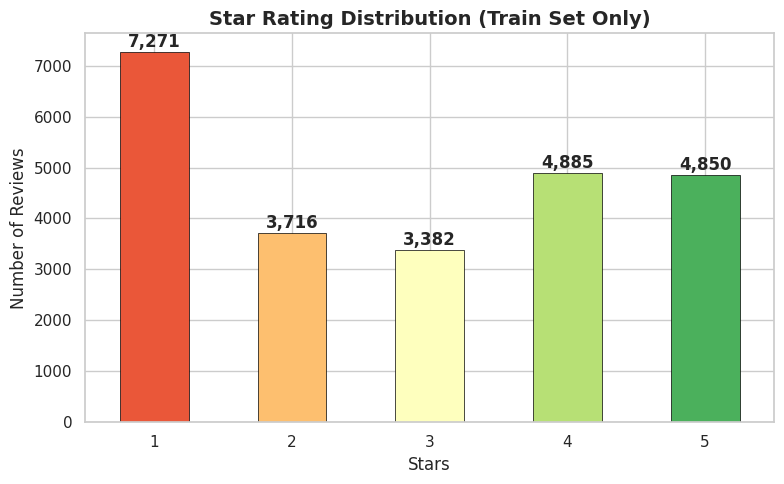

In [20]:
# Star rating distribution
fig, ax = plt.subplots(figsize=(8, 5))
train_df = df[df['note'].notna()]
rating_counts = train_df['note'].astype(int).value_counts().sort_index()
colors = sns.color_palette('RdYlGn', n_colors=5)
rating_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('Star Rating Distribution (Train Set Only)', fontsize=14, fontweight='bold')
ax.set_xlabel('Stars')
ax.set_ylabel('Number of Reviews')
for i, v in enumerate(rating_counts.values):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

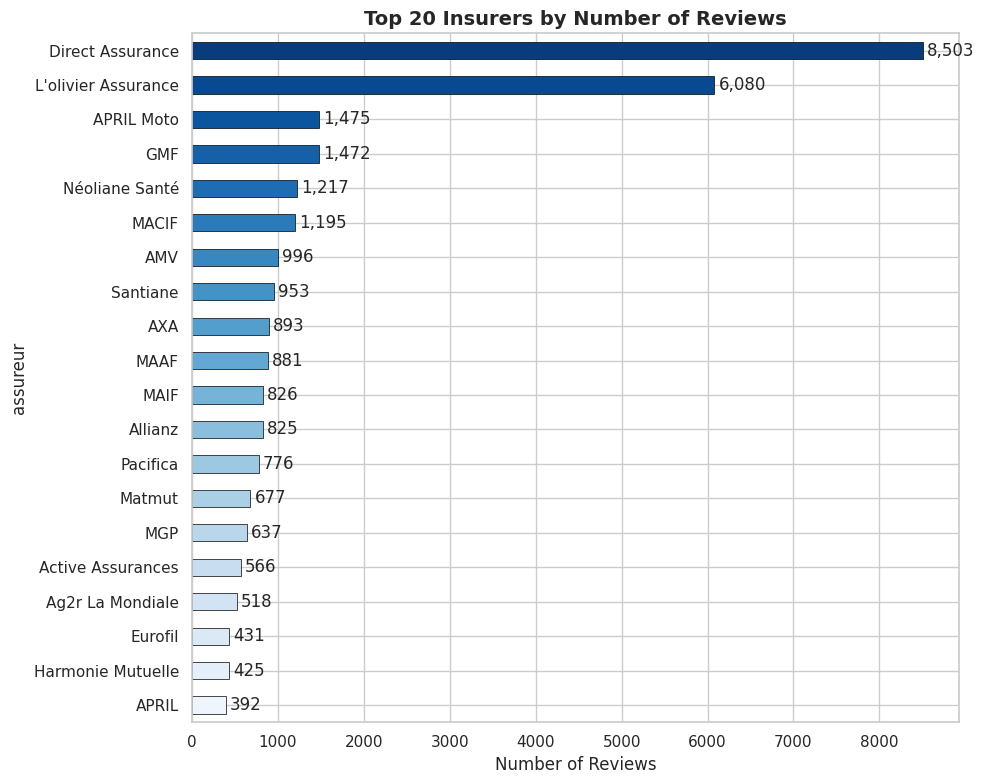


Total unique insurers: 56
Bottom 5: {'Magnolia': 25, 'Mapa': 12, 'MMA': 7, 'Sma': 7, 'Hiscox': 3}


In [21]:
# Reviews per insurer (top 20)
fig, ax = plt.subplots(figsize=(10, 8))
insurer_counts = df['assureur'].value_counts().head(20)
insurer_counts.plot(kind='barh', ax=ax, color=sns.color_palette('Blues_r', n_colors=20), edgecolor='black', linewidth=0.5)
ax.set_title('Top 20 Insurers by Number of Reviews', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Reviews')
ax.invert_yaxis()
for i, v in enumerate(insurer_counts.values):
    ax.text(v + 50, i, f'{v:,}', va='center')
plt.tight_layout()
plt.show()

print(f'\nTotal unique insurers: {df["assureur"].nunique()}')
print(f'Bottom 5: {df["assureur"].value_counts().tail(5).to_dict()}')

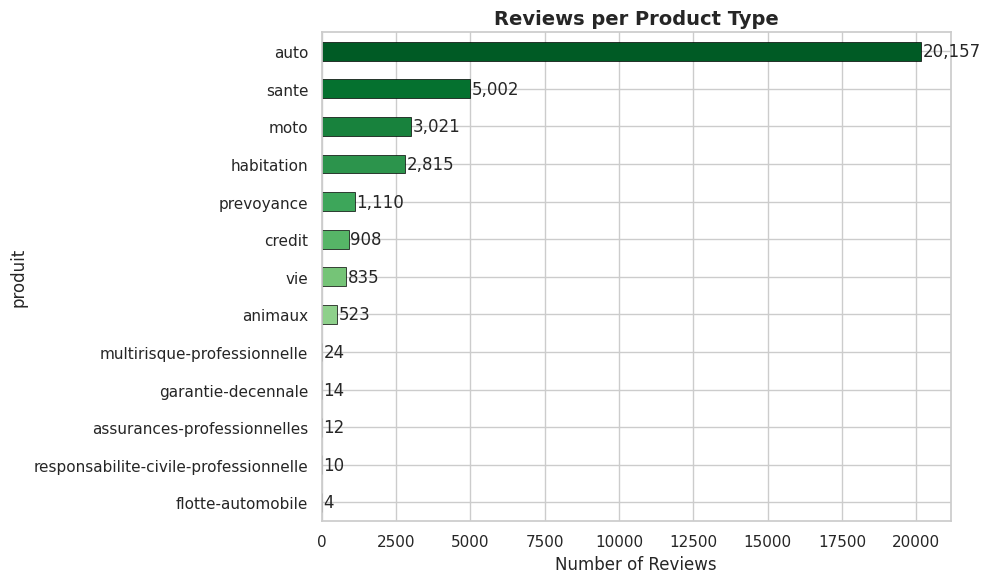

In [22]:
# Reviews per product type
fig, ax = plt.subplots(figsize=(10, 6))
product_counts = df['produit'].value_counts()
product_counts.plot(kind='barh', ax=ax, color=sns.color_palette('Greens_r', n_colors=len(product_counts)), edgecolor='black', linewidth=0.5)
ax.set_title('Reviews per Product Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Reviews')
ax.invert_yaxis()
for i, v in enumerate(product_counts.values):
    ax.text(v + 50, i, f'{v:,}', va='center')
plt.tight_layout()
plt.show()

### Visualization Observations

- **Star ratings**: 1-star reviews dominate (30% of train). 
- **Insurer concentration**: Top 2 insurers (Direct Assurance + L'olivier) account for 42% of all reviews. The long tail of 30+ insurers with <500 reviews each means insurer-level models will struggle with data scarcity.
- **Product imbalance**: `auto` alone is 58% of reviews. `sante` is a distant second at 15%. Niche products (garantie-decennale, flotte-automobile) have <25 reviews — unusable for per-product analysis.
- **Review timeline**: ~5 years of data (Nov 2016 — Nov 2021). Volume increases over time, with a clear spike around 2020-2021. No obvious seasonal pattern.
- **Review length**: Right-skewed with median ~200 chars. The log-scale view shows a smooth distribution with no anomalous clusters.

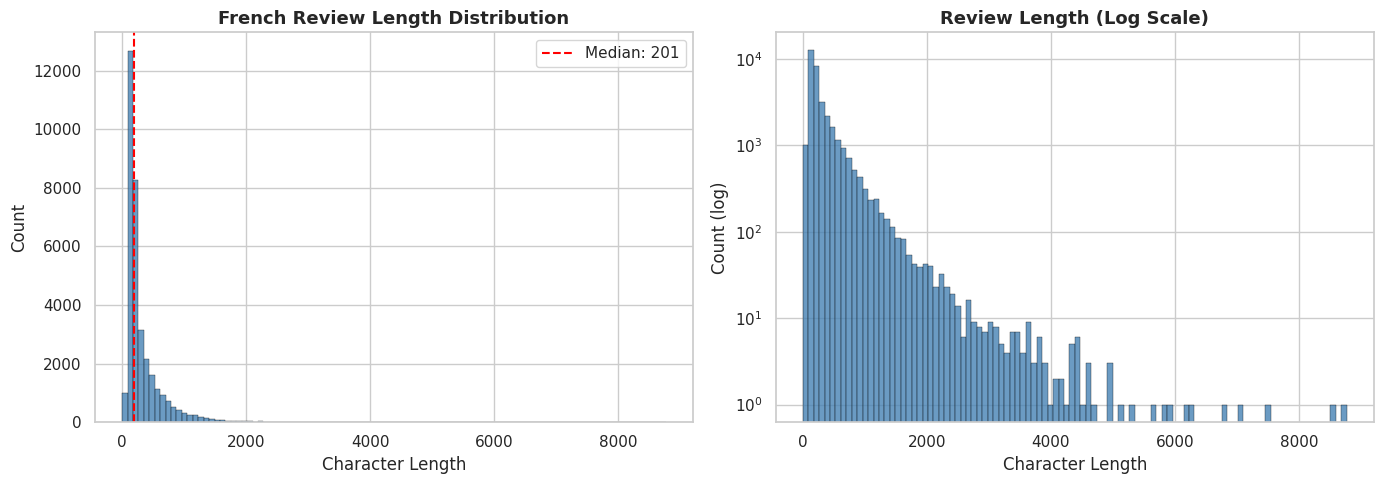

In [24]:
# Review length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['avis_len'], bins=100, color='steelblue', edgecolor='black', linewidth=0.3, alpha=0.8)
axes[0].set_title('French Review Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Count')
axes[0].axvline(df['avis_len'].median(), color='red', linestyle='--', label=f'Median: {df["avis_len"].median():.0f}')
axes[0].legend()

# Log scale for better view of tail
axes[1].hist(df['avis_len'], bins=100, color='steelblue', edgecolor='black', linewidth=0.3, alpha=0.8)
axes[1].set_title('Review Length (Log Scale)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Count (log)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

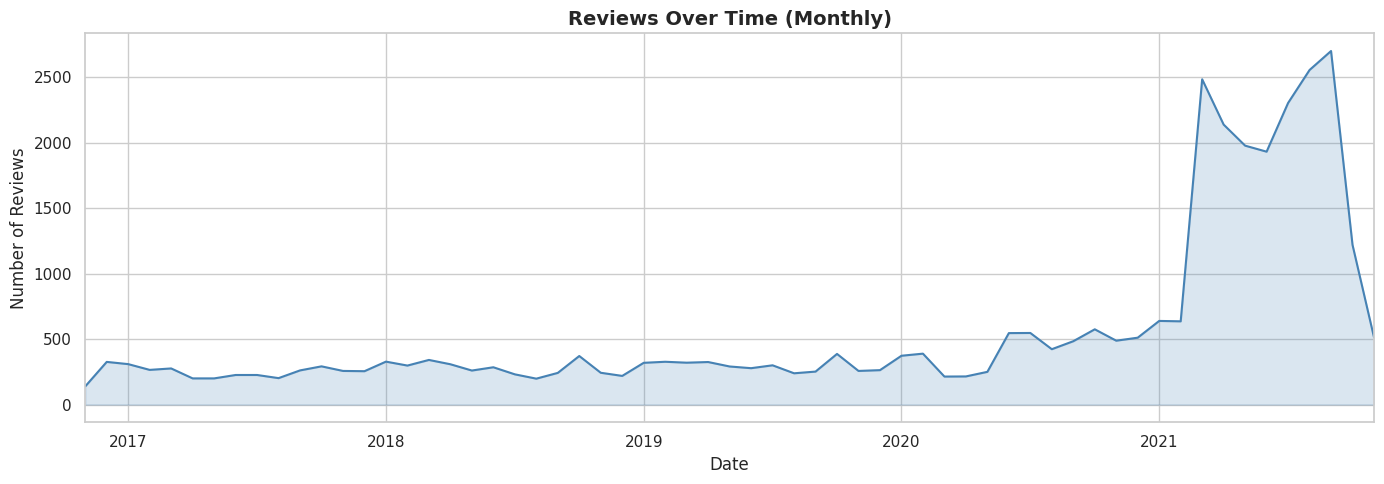

Date range: 2016-11-17 00:00:00 to 2021-11-16 00:00:00
Unparseable dates: 0


In [25]:
# Reviews over time
df['date_pub_parsed'] = pd.to_datetime(df['date_publication'], format='%d/%m/%Y', errors='coerce')

fig, ax = plt.subplots(figsize=(14, 5))
monthly = df.groupby(df['date_pub_parsed'].dt.to_period('M')).size()
monthly.index = monthly.index.to_timestamp()
monthly.plot(ax=ax, color='steelblue', linewidth=1.5)
ax.set_title('Reviews Over Time (Monthly)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Reviews')
ax.fill_between(monthly.index, monthly.values, alpha=0.2, color='steelblue')
plt.tight_layout()
plt.show()

print(f'Date range: {df["date_pub_parsed"].min()} to {df["date_pub_parsed"].max()}')
print(f'Unparseable dates: {df["date_pub_parsed"].isna().sum()}')

### Text Analysis Observations

- **Top English words** (from translations): "insurance", "service", "price", "good", "satisfied", "contract", "recommend" — insurance domain vocabulary dominates as expected. Sentiment words ("good", "satisfied", "recommend") are frequent, confirming reviews are opinion-heavy.
- **Sample reviews by star**: 1-star reviews tend to be longer and more detailed (specific complaints), while 5-star reviews are shorter and more generic ("super", "je recommande"). This is confirmed by the box plot — **negative reviews (1-2 stars) are significantly longer than positive ones (4-5 stars)**. The median length decreases monotonically from 1-star to 5-star.
- **Implication for classification**: Review length alone is a weak but usable feature for star prediction. The vocabulary difference between 1-star and 5-star is strong (complaints vs. praise), which should make sentiment classification feasible.

Using 33,329 English translations (excluded 1106 Loading.../NaN rows)



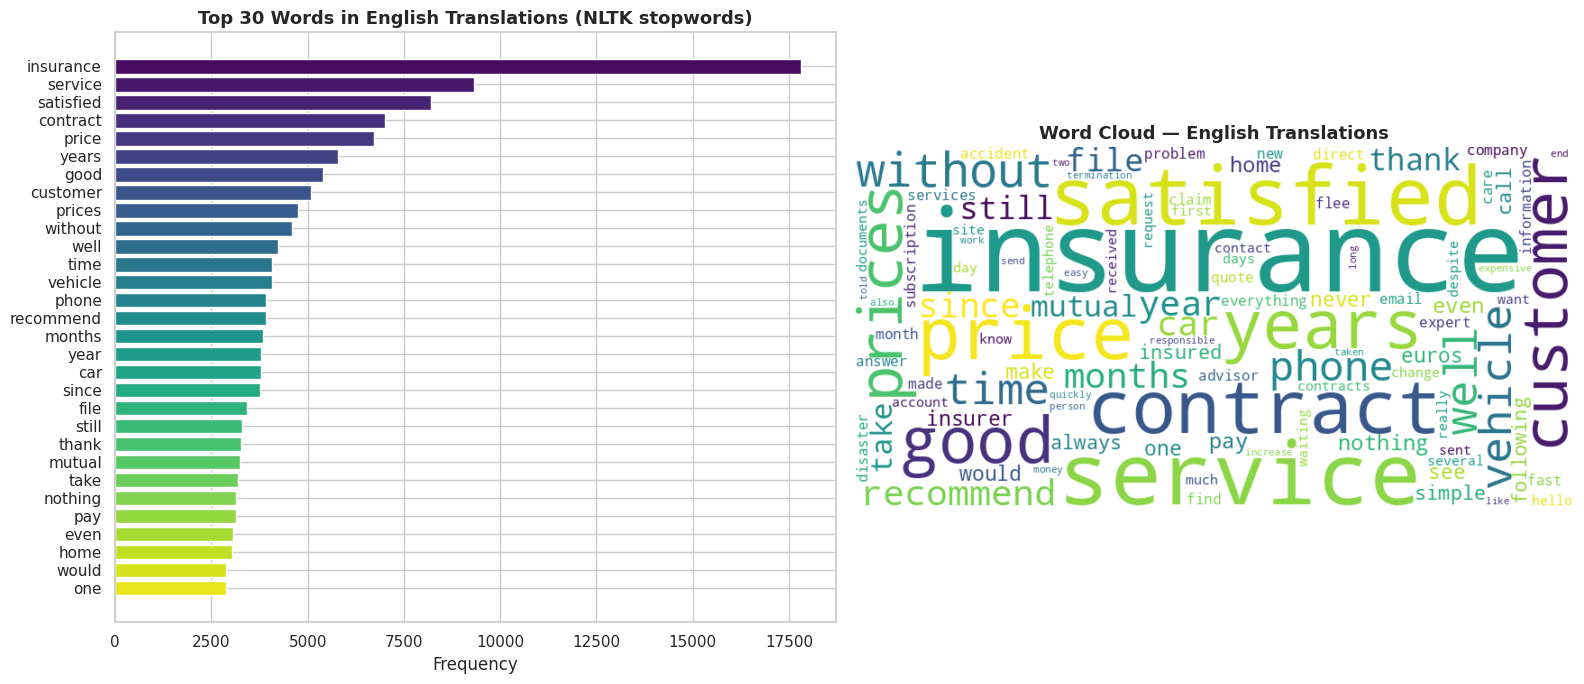

In [26]:
# Most frequent words in English translations (using NLTK stopwords)
# Use avis_en instead of avis — avoids hand-rolling French stopwords
# Exclude rows with "Loading..." or NaN translations
valid_en = df.loc[~is_loading & df['avis_en'].notna(), 'avis_en'].astype(str)
print(f'Using {len(valid_en):,} English translations (excluded {is_loading.sum() + df["avis_en"].isna().sum()} Loading.../NaN rows)\n')

all_words = []
for text in valid_en.values:
    words = re.findall(r'[a-z]+', text.lower())
    all_words.extend([w for w in words if w not in EN_STOPWORDS and len(w) > 2])

word_freq = Counter(all_words).most_common(30)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar chart
words, counts = zip(*word_freq)
axes[0].barh(range(len(words)), counts, color=sns.color_palette('viridis', n_colors=30))
axes[0].set_yticks(range(len(words)))
axes[0].set_yticklabels(words)
axes[0].invert_yaxis()
axes[0].set_title('Top 30 Words in English Translations (NLTK stopwords)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')

# Word cloud
wc = WordCloud(width=800, height=400, background_color='white', max_words=100,
               colormap='viridis', relative_scaling=0.5,
               stopwords=EN_STOPWORDS)
wc.generate_from_frequencies(dict(Counter(all_words).most_common(200)))
axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud — English Translations', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [27]:
# Sample reviews at each star level
print('=== Sample Reviews by Star Rating ===')
for star in [1, 2, 3, 4, 5]:
    subset = df[df['note'] == star]
    if len(subset) > 0:
        sample = subset.sample(1, random_state=42)
        print(f'\n--- {star} Star ({len(subset):,} reviews) ---')
        text = str(sample['avis'].values[0])
        print(f'{text[:300]}' + ('...' if len(text) > 300 else ''))
        print()

=== Sample Reviews by Star Rating ===

--- 1 Star (7,271 reviews) ---
Très déçu de cette assurance qui se dit moins chère que les autres. Je suis resté 5 ans chez eux. Avec un bonus à 0.8 en arrivant, 5 ans après mon bonus était à 0.6 et malgré tout sur les 5 années ma cotisation n'a pas arrêté d'augmenter. J'étais en tiers maxi pour une polo et je payais 58 par mois ...


--- 2 Star (3,716 reviews) ---
Mutuelle a fuir!!!!!Ne remboursent pas .Ne répondent pas ni aux mails ni au téléphone.Leur site internet est inaccessible.Par l’intermediaire du courtier,pas plus de résultats.


--- 3 Star (3,382 reviews) ---
Meli mélo entre 1 contrat résilié depuis plus d'1 an, et le nouveau contrat. Bien que n'ayant jamais subi de sinistre, je crains le pire pour l'avenir.


--- 4 Star (4,885 reviews) ---
Je suis très satisfait du service les personnes sont claire au téléphone ils ont bien à l'écoute du client mais les prix sont umpeut juste comparer à mon budget d'étudiants


--- 5 Star (4,850 revie

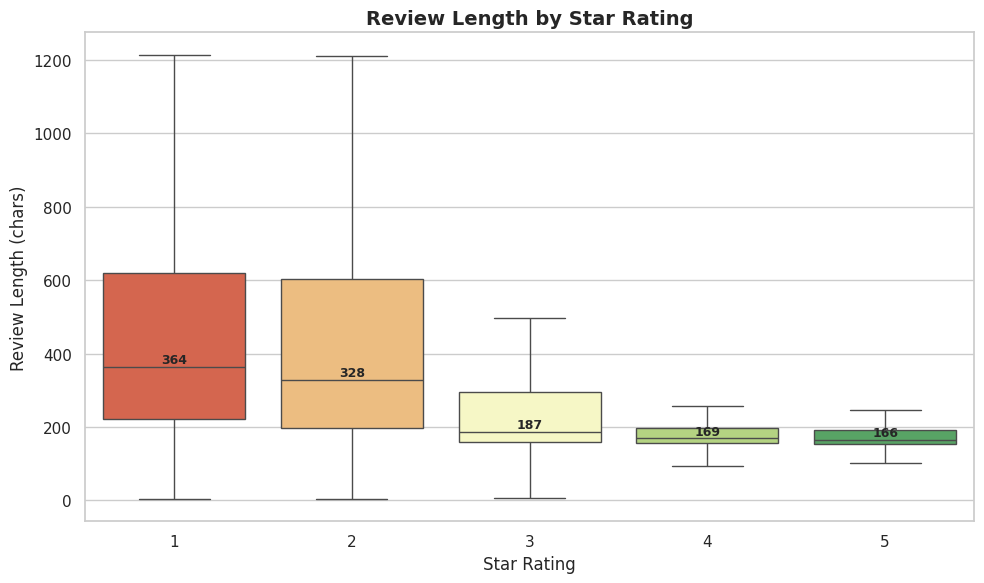

In [28]:
# Review length vs star rating (box plot)
fig, ax = plt.subplots(figsize=(10, 6))
train_with_len = train_df.copy()
train_with_len['note_int'] = train_with_len['note'].astype(int)
sns.boxplot(data=train_with_len, x='note_int', y='avis_len', ax=ax,
            palette='RdYlGn', showfliers=False)
ax.set_title('Review Length by Star Rating', fontsize=14, fontweight='bold')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Review Length (chars)')

# Add median labels
medians = train_with_len.groupby('note_int')['avis_len'].median()
for i, (star, med) in enumerate(medians.items()):
    ax.text(i, med + 10, f'{med:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Step 2 — Save Clean Exploration Outputs

In [29]:
# Save raw_combined.csv (drop helper columns + useless avis_cor/avis_cor_en, keep source_file)
drop_cols = ['avis_len', 'avis_en_len', 'date_pub_parsed', 'avis_cor', 'avis_cor_en']
raw_cols = [c for c in df.columns if c not in drop_cols]
df[raw_cols].to_csv(OUT_DIR / 'raw_combined.csv', index=False)
print(f'Saved data/raw_combined.csv: {len(df):,} rows x {len(raw_cols)} cols')
print(f'Columns: {raw_cols}')
print(f'Dropped avis_cor/avis_cor_en (98.7% NaN, only 2 actual corrections)')

Saved data/raw_combined.csv: 34,435 rows x 10 cols
Columns: ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'source_file']
Dropped avis_cor/avis_cor_en (98.7% NaN, only 2 actual corrections)


In [30]:
# Reload and verify
raw_check = pd.read_csv(OUT_DIR / 'raw_combined.csv')

print('=== Verification ===')
print(f'raw_combined.csv rows: {len(raw_check):,} (expected ~34,435)')

train_count = raw_check['note'].notna().sum()
test_count = raw_check['note'].isna().sum()
print(f'Train/test split: {train_count:,} / {test_count:,}')
print(f'Columns: {list(raw_check.columns)}')

dropped = 'avis_cor' not in raw_check.columns and 'avis_cor_en' not in raw_check.columns
print(f'avis_cor/avis_cor_en dropped: {dropped}')
print('\nAll checks passed.')

=== Verification ===
raw_combined.csv rows: 34,435 (expected ~34,435)
Train/test split: 24,104 / 10,331
Columns: ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'source_file']
avis_cor/avis_cor_en dropped: True

All checks passed.
